# Six-Face Test: Calibration

TODO: should i really compute stationary intervals based on raw data? Or should I use the calibrated data?

Use this notebook to compute the calibration parameters with the data from the stationary captures.

## Setup

In [160]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import numpy as np
import matplotlib.pyplot as plt
import math

G = 9.80665

reader = IMUSampleReader()
sixFaceStationaryCaptures = [
    "../0-capture/stationary/may-2026/pos-x-up.csv",
    "../0-capture/stationary/may-2026/neg-x-up.csv",
    "../0-capture/stationary/may-2026/pos-y-up.csv",
    "../0-capture/stationary/may-2026/neg-y-up.csv",
    "../0-capture/stationary/may-2026/pos-z-up.csv",
    "../0-capture/stationary/may-2026/neg-z-up.csv",
]
tiltedStationaryCaptures = [
    "../0-capture/stationary/jul-25-2026/pos-x-pos-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/neg-x-pos-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/pos-y-pos-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/neg-y-pos-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/pos-x-neg-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/neg-x-neg-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/pos-y-neg-z-tilt.csv",
    "../0-capture/stationary/jul-25-2026/neg-y-neg-z-tilt.csv",
]
rawOrientations = [
    reader.readRaw(file)
    for file in [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]
]

simpleRotationsCaptures = [
    "../0-capture/simple-rotations/jun-2026/rot-x-hw.csv",
    "../0-capture/simple-rotations/jun-2026/rot-y-hw.csv",
    "../0-capture/simple-rotations/jun-2026/rot-z-hw.csv",
]

realExerciseCaptures = [
    "../0-capture/real-exercises/apr-28-2026/dips-1.csv",
    "../0-capture/real-exercises/apr-28-2026/dips-2.csv",
    "../0-capture/real-exercises/apr-28-2026/dips-3.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-1.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-2.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-3.csv",
    "../0-capture/real-exercises/apr-28-2026/90-deg-push-ups-1.csv",
    "../0-capture/real-exercises/apr-28-2026/90-deg-push-ups-2.csv",
]

writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(sixFaceStationaryCaptures)

Acceleration norms:	Mean = 9.890416
	Stdev = 0.251631
	Stationary tol = 1.258153
Gyroscope norms: 	Stdev = 2.328577
	Stationary tol = 6.985731


## Accelerometer 

View accelerometer calibration as an affine transformation (rotation, shear, scaling, translation) applied to the raw sensor data to obtain the true physical values. Consider the linear system:

$$
\mathbf{A} \mathbf{x} = \mathbf{b} \\
 \mathbf{x} = (\mathbf{A}^t \mathbf{A})^{-1} \mathbf{A}^t \mathbf{b}
$$

Where:
- $\mathbf{A}$: the mean of raw sensor readings in the six faces and tilted orientations. This is valid since standard deviations are tight overall, as seen in `1-analysis.ipynb`.
- $\mathbf{b}$: matrix with desired calibration values (true g vector at different orientations).
- $\mathbf{x}$: transformation matrix obtained with least squares. 

Alternatives:
- Just substracting the bias (mean of each axis across all orientations) from the raw data. Too simple and maybe error prone.
- Using the current approach with many linear transformations for at least two known temperatures and use interpolation to get the parameters for any temperature. Feasible since the IMU measures temperature too, I can craft another device for temperature measurement with my Arduino Uno and a DHT11 sensor and can use a heater from home. Much more work and maybe the difference is not significant enough to justify it.
- Using some non-linear transformation. More precise but much more complex.

Sources: 
- https://cookierobotics.com/061/
- Linear Algebra - Stanley Grossman: 6.2. Approximation by Least Squares

In [161]:
def computeAffineTransformationMatrix(captures, b):
    A = np.ones((len(captures), 4))
    for i, capture in enumerate(captures):
        _, a, _ = reader.readRaw(capture)
        ax = np.mean(a[:, 0])
        ay = np.mean(a[:, 1])
        az = np.mean(a[:, 2])

        # 1: independent term for bias
        A[i] = [ax, ay, az, 1]

    return np.linalg.pinv(A) @ b


b1 = np.zeros((len(sixFaceStationaryCaptures), 3))
b1[0][0] = G
b1[1][0] = -G
b1[2][1] = G
b1[3][1] = -G
b1[4][2] = G
b1[5][2] = -G
x1 = computeAffineTransformationMatrix(sixFaceStationaryCaptures, b1)
print(f"\nx(six-face) =\n{x1}")

b2 = np.zeros((len(tiltedStationaryCaptures), 3))
b2[0, :] = [-G / math.sqrt(2), 0, -G / math.sqrt(2)]
b2[1, :] = [G / math.sqrt(2), 0.0, -G / math.sqrt(2)]
b2[2, :] = [0.0, -G / math.sqrt(2), -G / math.sqrt(2)]
b2[3, :] = [0.0, G / math.sqrt(2), -G / math.sqrt(2)]
b2[4, :] = [-G / math.sqrt(2), 0.0, G / math.sqrt(2)]
b2[5, :] = [G / math.sqrt(2), 0.0, G / math.sqrt(2)]
b2[6, :] = [0.0, -G / math.sqrt(2), G / math.sqrt(2)]
b2[7, :] = [0.0, G / math.sqrt(2), G / math.sqrt(2)]
x2 = computeAffineTransformationMatrix(tiltedStationaryCaptures, b2)
print(f"\nx(tilted) =\n{x2}")

b3 = np.vstack((b1, b2))
x3 = computeAffineTransformationMatrix(
    [*sixFaceStationaryCaptures, *tiltedStationaryCaptures], b3
)
print(f"\nx(six-face+tilted) =\n{x3}")


x(six-face) =
[[ 0.99878374 -0.00933288  0.02040961]
 [ 0.01210606  0.99696514 -0.01862394]
 [-0.01313606 -0.00642989  0.98043959]
 [-0.32646267 -0.16230203 -0.1406934 ]]

x(tilted) =
[[ 1.00252078 -0.0163107   0.01924378]
 [ 0.01719244  0.99666423 -0.00306837]
 [-0.01413914 -0.00164249  0.97782571]
 [-0.27224623 -0.17406578 -0.13161548]]

x(six-face+tilted) =
[[ 1.00061492 -0.01278239  0.01981899]
 [ 0.01466471  0.99677492 -0.01082454]
 [-0.0138142  -0.00325066  0.97864321]
 [-0.29535118 -0.16915523 -0.13522794]]


In [162]:
def calibrateAccel(a, withCaptures="both"):
    if withCaptures == "six-face":
        x = x1
    elif withCaptures == "tilted":
        x = x2
    else:
        x = x3
    # Augment acceleration data with a constant 1 for the affine term
    aAugmented = np.hstack([a, np.ones((a.shape[0], 1))])
    # x is 4x3: aAugmented @ x => Nx3 calibrated accelerations
    return aAugmented @ x


def plotRawAndCalibratedAccelSeries(captures):
    rows = len(captures)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

    for i, capture in enumerate(captures):
        seq, a, w = reader.readRaw(capture)
        aCalibratedSixFace = calibrateAccel(a, "six-face")
        aCalibratedTilted = calibrateAccel(a, "tilted")
        aCalibratedBoth = calibrateAccel(a, "both")
        stationaryPeriods = stationaryChecker.findStationaryIntervals(seq, a, w)

        axes[i, 1].set_title(capture)
        for j in range(3):
            for lower, upper in stationaryPeriods:
                axes[i, j].axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

            aMax = np.max(a[:, j])
            aMin = np.min(a[:, j])
            linesTol = 0.125
            if aMax > (1 - linesTol) * G:
                axes[i, j].axhline(
                    G,
                    color="black",
                    linestyle="-",
                    label="g",
                    zorder=1,
                )
            if aMax < (1 - linesTol) * G and aMax > (1 - linesTol) * G / math.sqrt(2):
                axes[i, j].axhline(
                    G / math.sqrt(2),
                    color="black",
                    linestyle="--",
                    label="g/sqrt(2)",
                    zorder=1,
                )
            if aMax > -linesTol and aMin < linesTol:
                axes[i, j].axhline(0, color="black", linestyle="-", zorder=1)
            if aMin < -(1 - linesTol) * G / math.sqrt(2) and aMin > -(1 - linesTol) * G:
                axes[i, j].axhline(
                    -G / math.sqrt(2),
                    color="black",
                    linestyle="--",
                    label="-g/sqrt(2)",
                    zorder=1,
                )
            if aMin < -(1 - linesTol) * G:
                axes[i, j].axhline(
                    -G,
                    color="black",
                    linestyle="-",
                    label="-g",
                    zorder=1,
                )

            axes[i, j].plot(seq, a[:, j], label="Raw", color="blue")
            axes[i, j].plot(
                seq,
                aCalibratedSixFace[:, j],
                label="Calibrated (six-face)",
                color="green",
            )
            axes[i, j].plot(
                seq,
                aCalibratedTilted[:, j],
                label="Calibrated (tilted)",
                color="orange",
            )
            axes[i, j].plot(
                seq,
                aCalibratedBoth[:, j],
                label="Calibrated (six-face + tilted)",
                color="red",
            )
            axes[i, j].set_xlabel("Sequence number")
            axes[i, j].set_ylabel(f"{['ax', 'ay', 'az'][j]} (m/s^2)")
            axes[i, j].legend()
            axes[i, j].grid()
    fig.tight_layout()
    plt.show()

### Graphical inspection: stationary captures

The transformation matrix computed from the six-face captures is not necessary the closest to the real values in all six face captures. This also verifies for the tilted transformation matrix and tilted captures. The matrix obtained from both captures lies generally at a middle point between the two. There are, in some cases, non-trivial residual accelerations in the calibrated data (worst case: 0.1-0.2 m/s²). Just by looking at graphs there's no clear winner between matrices, but using all captures may make more sense. 

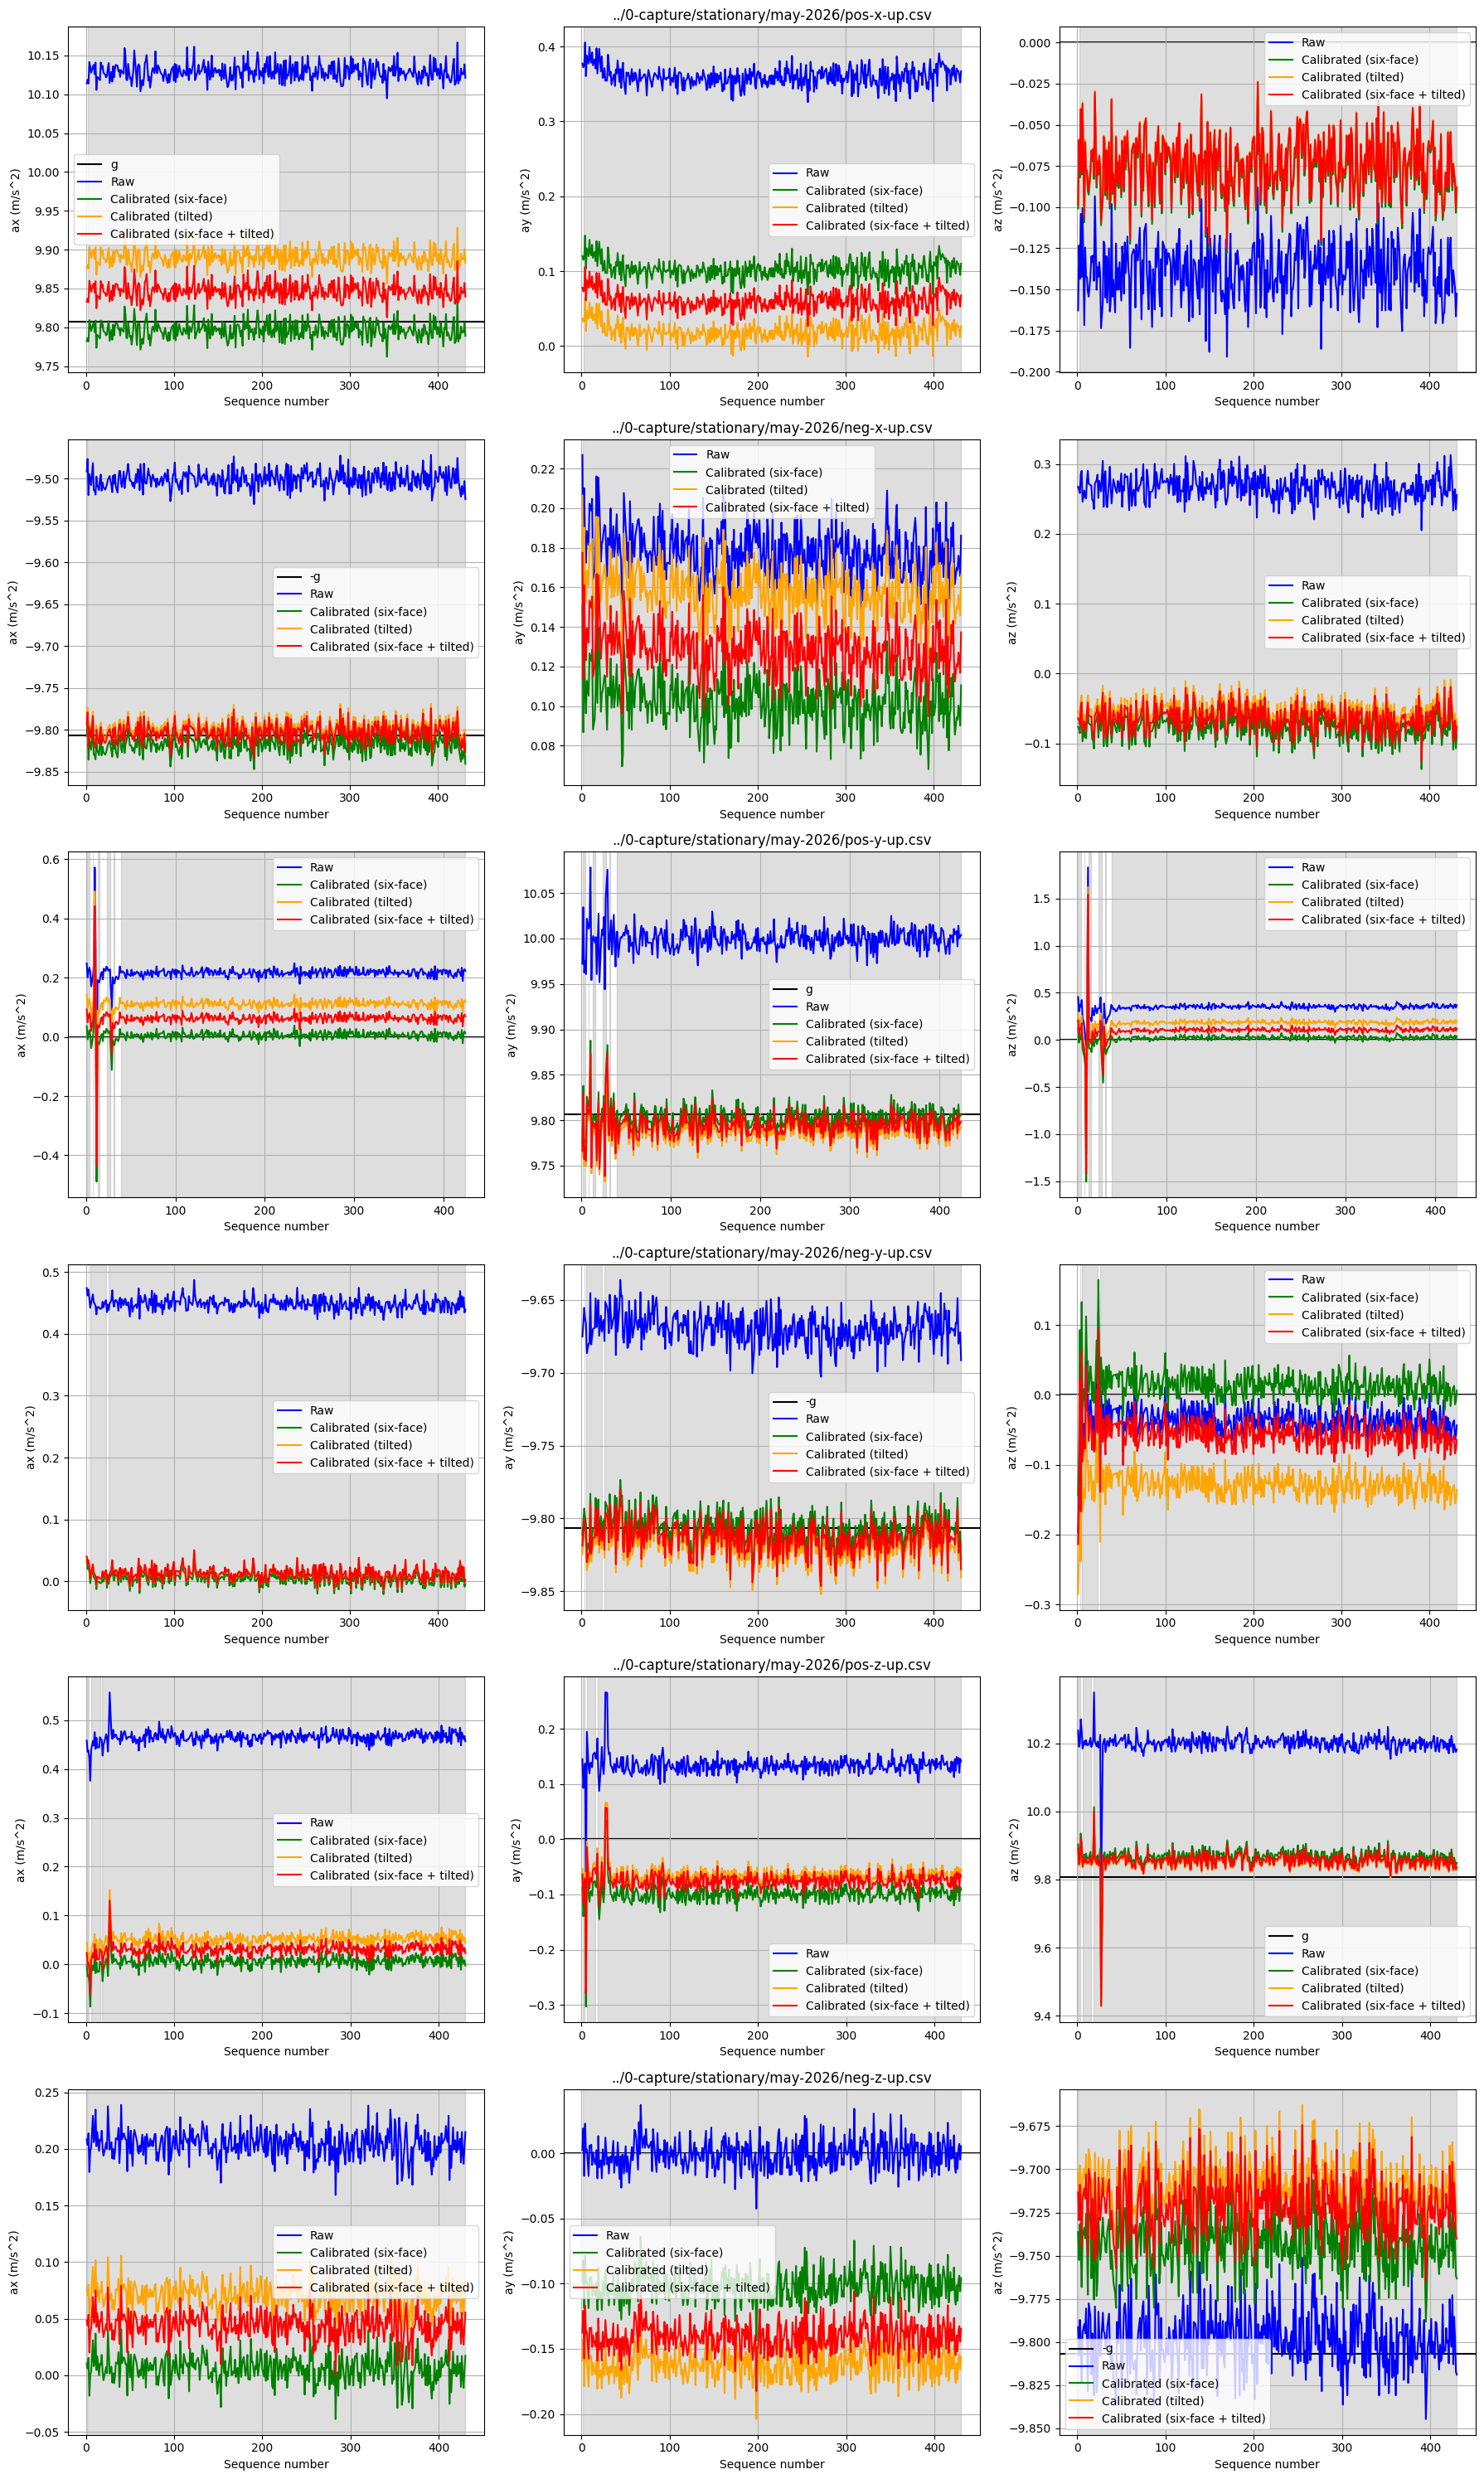

In [163]:
plotRawAndCalibratedAccelSeries(sixFaceStationaryCaptures)

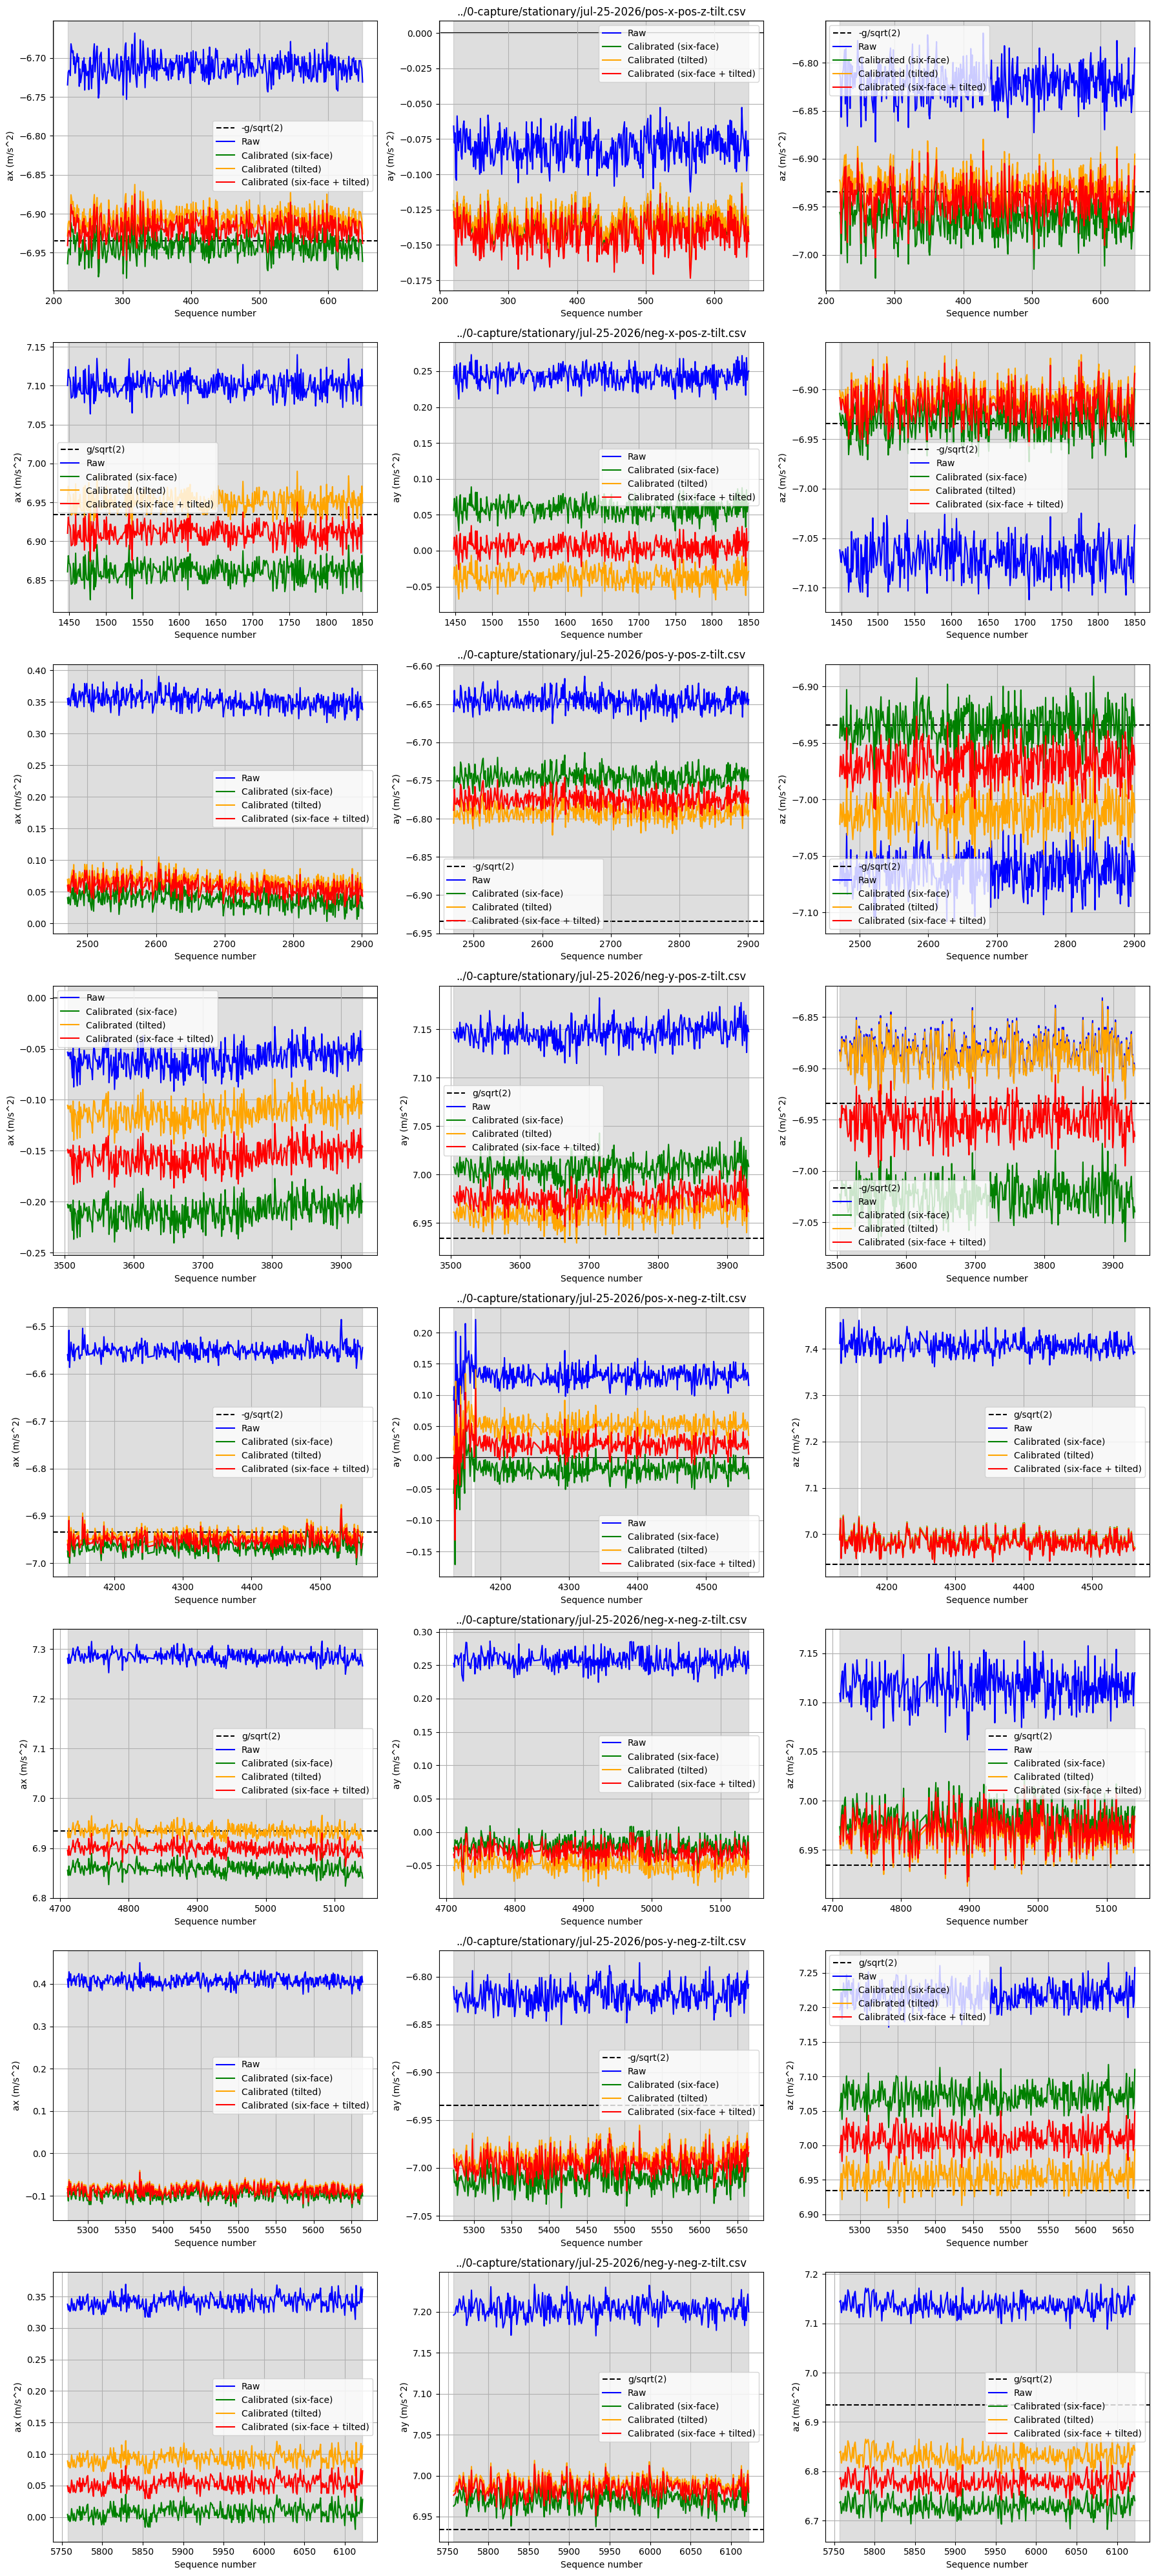

In [164]:
plotRawAndCalibratedAccelSeries(tiltedStationaryCaptures)

### Graphical inspection: simple rotations captures

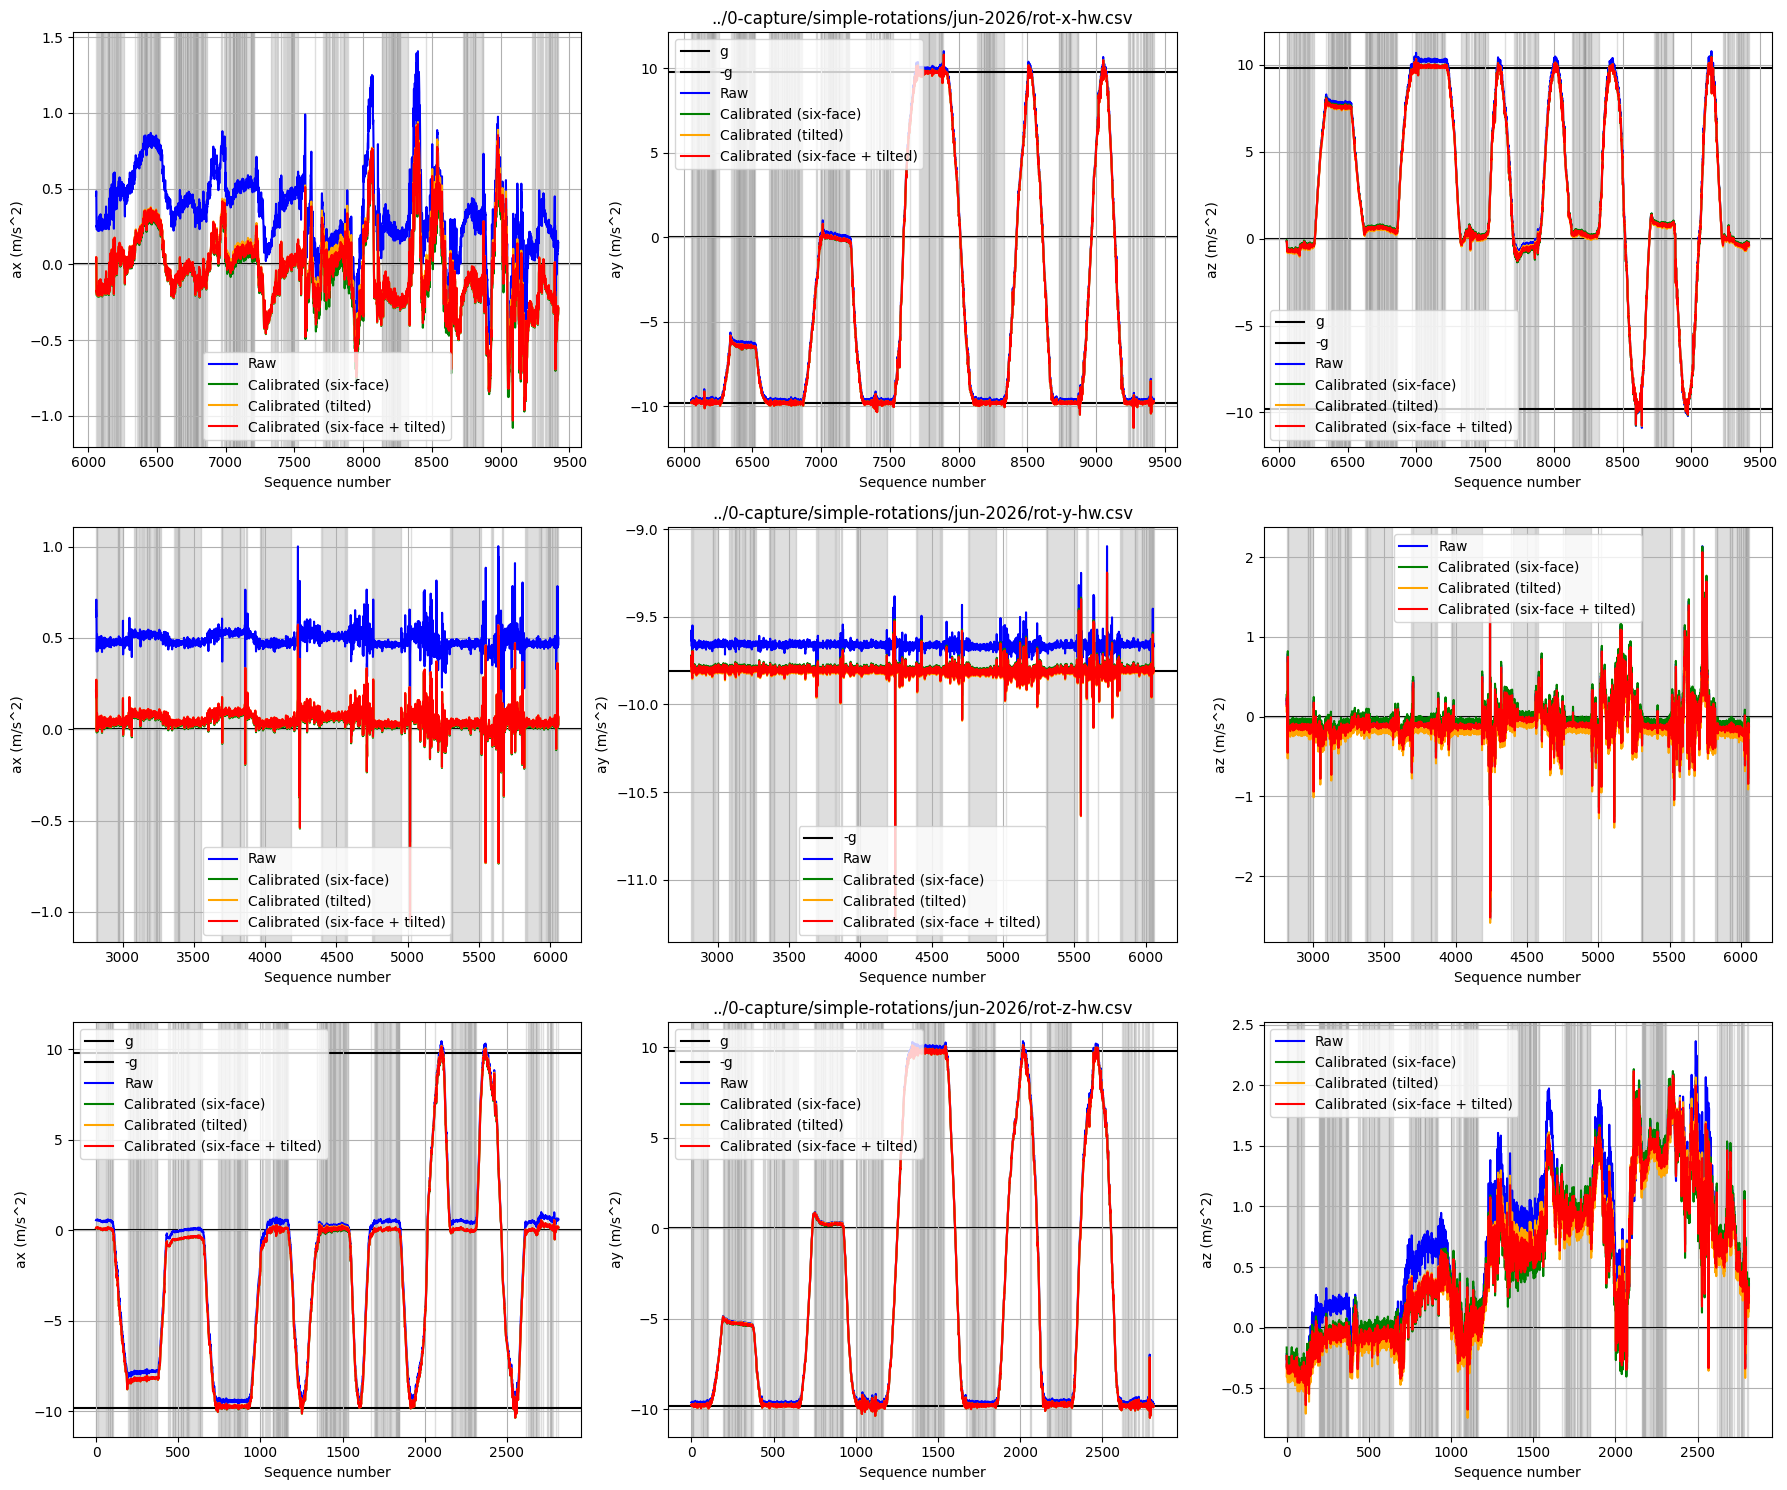

In [165]:
plotRawAndCalibratedAccelSeries(simpleRotationsCaptures)

### Numerical inspection: stationary captures

Using both the six-face and tilted captures for the transformation matrix yields the best results globally, with a mean residual about one order of magnitude lower than using only one of the two types of captures. For the RMS and standard, the improvements are moderate but still significant. However, locally there are cases where the six-face captures yield better results than the tilted captures, and vice versa, and using both captures yields results in between the two.  
Unfortunately, there are still residual accelerations of the order of 0.1m/s² in some spare captures, which may be significant, since integration accumulates errors quickly. If this is the case, it may be necessary to use another mechanism down the pipeline such as online acceleration calibration. 

In [177]:
def computeAccelCalibrationMetrics(captures, gVectors):
    axes = ["ax", "ay", "az"]
    gravityAffectedDiffsPerAxisSixFace = [[], [], []]
    gravityAffectedDiffsPerAxisTilted = [[], [], []]
    gravityAffectedDiffsPerAxisBoth = [[], [], []]
    gravityFreeDiffsPerAxisSixFace = [[], [], []]
    gravityFreeDiffsPerAxisTilted = [[], [], []]
    gravityFreeDiffsPerAxisBoth = [[], [], []]

    for i, capture in enumerate(captures):
        _, a, w = reader.readRaw(capture)
        stationaryFlags = stationaryChecker.areStationarySamples(a, w)
        aCalibratedStationarySixFace = np.array(
            [
                aCal
                for i, aCal in enumerate(calibrateAccel(a, "six-face"))
                if stationaryFlags[i]
            ]
        )
        aCalibratedStationaryTilted = np.array(
            [
                aCal
                for i, aCal in enumerate(calibrateAccel(a, "tilted"))
                if stationaryFlags[i]
            ]
        )
        aCalibratedStationaryBoth = np.array(
            [
                aCal
                for i, aCal in enumerate(calibrateAccel(a, "both"))
                if stationaryFlags[i]
            ]
        )

        print(f"{capture}:")
        for j, axisName in enumerate(axes):
            axisMeanSixFace = np.mean(aCalibratedStationarySixFace[:, j])
            axisMeanTilted = np.mean(aCalibratedStationaryTilted[:, j])
            axisMeanBoth = np.mean(aCalibratedStationaryBoth[:, j])
            print(f"\t{axisName}:")
            gTol = 0.05 * G
            if abs(gVectors[i][j]) > gTol:
                axisDiffsSixFace = (
                    aCalibratedStationarySixFace[:, j]
                    - np.ones_like(aCalibratedStationarySixFace[:, j]) * gVectors[i][j]
                )
                axisDiffsTilted = (
                    aCalibratedStationaryTilted[:, j]
                    - np.ones_like(aCalibratedStationaryTilted[:, j]) * gVectors[i][j]
                )
                axisDiffsBoth = (
                    aCalibratedStationaryBoth[:, j]
                    - np.ones_like(aCalibratedStationaryBoth[:, j]) * gVectors[i][j]
                )
                print(
                    f"\t\tmean: "
                    f"six-face={axisMeanSixFace:.4f} (diff={np.mean(axisDiffsSixFace):.4f}),",
                    f"tilted={axisMeanTilted:.4f} (diff={np.mean(axisDiffsTilted):.4f}),",
                    f"both={axisMeanBoth:.4f} (diff={np.mean(axisDiffsBoth):.4f})",
                )

                rmsSixFace = np.sqrt(np.mean((axisDiffsSixFace) ** 2))
                rmsTilted = np.sqrt(np.mean((axisDiffsTilted) ** 2))
                rmsBoth = np.sqrt(np.mean((axisDiffsBoth) ** 2))
                print(
                    f"\t\tRMS: six-face={rmsSixFace:.4f}, tilted={rmsTilted:.4f}, both={rmsBoth:.4f}"
                )

                gravityAffectedDiffsPerAxisSixFace[j].append(axisDiffsSixFace)
                gravityAffectedDiffsPerAxisTilted[j].append(axisDiffsTilted)
                gravityAffectedDiffsPerAxisBoth[j].append(axisDiffsBoth)
            else:
                print(
                    f"\t\tmean: six-face={axisMeanSixFace:.4f}, tilted={axisMeanTilted:.4f}, both={axisMeanBoth:.4f}",
                )

                rmsSixFace = np.sqrt(np.mean(aCalibratedStationarySixFace[:, j] ** 2))
                rmsTilted = np.sqrt(np.mean(aCalibratedStationaryTilted[:, j] ** 2))
                rmsBoth = np.sqrt(np.mean(aCalibratedStationaryBoth[:, j] ** 2))
                print(
                    f"\t\tRMS: six-face={rmsSixFace:.4f}, tilted={rmsTilted:.4f}, both={rmsBoth:.4f}"
                )

                gravityFreeDiffsPerAxisSixFace[j].append(
                    aCalibratedStationarySixFace[:, j]
                )
                gravityFreeDiffsPerAxisTilted[j].append(
                    aCalibratedStationaryTilted[:, j]
                )
                gravityFreeDiffsPerAxisBoth[j].append(aCalibratedStationaryBoth[:, j])

            stdSixFace = np.std(aCalibratedStationarySixFace[:, j])
            stdTilted = np.std(aCalibratedStationaryTilted[:, j])
            stdBoth = np.std(aCalibratedStationaryBoth[:, j])
            print(
                f"\t\tstd: six-face={stdSixFace:.4f}, tilted={stdTilted:.4f}, both={stdBoth:.4f}"
            )
        print("")

    print(
        "____________________________________________________________________________"
    )
    print(f"Residuals metrics: ")

    gravityFreeDiffsPerAxisSixFace = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityFreeDiffsPerAxisSixFace
    ]
    gravityFreeDiffsPerAxisTilted = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityFreeDiffsPerAxisTilted
    ]
    gravityFreeDiffsPerAxisBoth = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityFreeDiffsPerAxisBoth
    ]
    print("Gravity free:")
    for j, axisName in enumerate(axes):
        print(
            f"\t{axisName}:"
            f"\n\t\tmean: six-face={np.mean(gravityFreeDiffsPerAxisSixFace[j]):.6f}, tilted={np.mean(gravityFreeDiffsPerAxisTilted[j]):.6f}, both={np.mean(gravityFreeDiffsPerAxisBoth[j]):.6f}"
            f"\n\t\tRMS: six-face={np.sqrt(np.mean(gravityFreeDiffsPerAxisSixFace[j]**2)):.6f}, tilted={np.sqrt(np.mean(gravityFreeDiffsPerAxisTilted[j]**2)):.6f}, both={np.sqrt(np.mean(gravityFreeDiffsPerAxisBoth[j]**2)):.6f}"
            f"\n\t\tstd: six-face={np.std(gravityFreeDiffsPerAxisSixFace[j]):.6f}, tilted={np.std(gravityFreeDiffsPerAxisTilted[j]):.6f}, both={np.std(gravityFreeDiffsPerAxisBoth[j]):.6f}"
        )

    gravityAffectedDiffsPerAxisSixFace = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityAffectedDiffsPerAxisSixFace
    ]
    gravityAffectedDiffsPerAxisTilted = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityAffectedDiffsPerAxisTilted
    ]
    gravityAffectedDiffsPerAxisBoth = [
        np.concatenate(axisDiffs) if len(axisDiffs) > 0 else np.array([])
        for axisDiffs in gravityAffectedDiffsPerAxisBoth
    ]
    print("Affected by gravity:")
    for j, axisName in enumerate(axes):
        print(
            f"\t{axisName}:"
            f"\n\t\tmean: six-face={np.mean(gravityAffectedDiffsPerAxisSixFace[j]):.6f}, tilted={np.mean(gravityAffectedDiffsPerAxisTilted[j]):.6f}, both={np.mean(gravityAffectedDiffsPerAxisBoth[j]):.6f}"
            f"\n\t\tRMS: six-face={np.sqrt(np.mean(gravityAffectedDiffsPerAxisSixFace[j]**2)):.6f}, tilted={np.sqrt(np.mean(gravityAffectedDiffsPerAxisTilted[j]**2)):.6f}, both={np.sqrt(np.mean(gravityAffectedDiffsPerAxisBoth[j]**2)):.6f}"
            f"\n\t\tstd: six-face={np.std(gravityAffectedDiffsPerAxisSixFace[j]):.6f}, tilted={np.std(gravityAffectedDiffsPerAxisTilted[j]):.6f}, both={np.std(gravityAffectedDiffsPerAxisBoth[j]):.6f}"
        )

    generalDiffsPerAxisSixFace = [
        np.concatenate(
            [gravityAffectedDiffsPerAxisSixFace[j], gravityFreeDiffsPerAxisSixFace[j]]
        )
        for j in range(len(axes))
    ]
    generalDiffsPerAxisTilted = [
        np.concatenate(
            [gravityAffectedDiffsPerAxisTilted[j], gravityFreeDiffsPerAxisTilted[j]]
        )
        for j in range(len(axes))
    ]
    generalDiffsPerAxisBoth = [
        np.concatenate(
            [gravityAffectedDiffsPerAxisBoth[j], gravityFreeDiffsPerAxisBoth[j]]
        )
        for j in range(len(axes))
    ]
    print("Gravity affected + gravity free:")
    for j, axisName in enumerate(axes):
        print(
            f"\t{axisName}:"
            f"\n\t\tmean: six-face={np.mean(generalDiffsPerAxisSixFace[j]):.6f}, tilted={np.mean(generalDiffsPerAxisTilted[j]):.6f}, both={np.mean(generalDiffsPerAxisBoth[j]):.6f}"
            f"\n\t\tRMS: six-face={np.sqrt(np.mean(generalDiffsPerAxisSixFace[j]**2)):.6f}, tilted={np.sqrt(np.mean(generalDiffsPerAxisTilted[j]**2)):.6f}, both={np.sqrt(np.mean(generalDiffsPerAxisBoth[j]**2)):.6f}"
            f"\n\t\tstd: six-face={np.std(generalDiffsPerAxisSixFace[j]):.6f}, tilted={np.std(generalDiffsPerAxisTilted[j]):.6f}, both={np.std(generalDiffsPerAxisBoth[j]):.6f}"
        )

    globalDiffsSixFace = np.concatenate(generalDiffsPerAxisSixFace)
    globalDiffsTilted = np.concatenate(generalDiffsPerAxisTilted)
    globalDiffsBoth = np.concatenate(generalDiffsPerAxisBoth)
    print(
        "\tAll axes:"
        f"\n\t\tmean: six-face={np.mean(globalDiffsSixFace):.6f}, tilted={np.mean(globalDiffsTilted):.6f}, both={np.mean(globalDiffsBoth):.6f}"
        f"\n\t\tRMS: six-face={np.sqrt(np.mean(globalDiffsSixFace**2)):.6f}, tilted={np.sqrt(np.mean(globalDiffsTilted**2)):.6f}, both={np.sqrt(np.mean(globalDiffsBoth**2)):.6f}"
        f"\n\t\tstd: six-face={np.std(globalDiffsSixFace):.6f}, tilted={np.std(globalDiffsTilted):.6f}, both={np.std(globalDiffsBoth):.6f}"
    )


computeAccelCalibrationMetrics(
    [*sixFaceStationaryCaptures, *tiltedStationaryCaptures], b3
)

../0-capture/stationary/may-2026/pos-x-up.csv:
	ax:
		mean: six-face=9.7961 (diff=-0.0105), tilted=9.8901 (diff=0.0835), both=9.8468 (diff=0.0401)
		RMS: six-face=0.0152, tilted=0.0842, both=0.0416
		std: six-face=0.0109, tilted=0.0109, both=0.0109
	ay:
		mean: six-face=0.1026, tilted=0.0194, both=0.0603
		RMS: six-face=0.1034, tilted=0.0232, both=0.0616
		std: six-face=0.0127, tilted=0.0127, both=0.0127
	az:
		mean: six-face=-0.0770, tilted=-0.0737, both=-0.0744
		RMS: six-face=0.0789, tilted=0.0757, both=0.0764
		std: six-face=0.0172, tilted=0.0171, both=0.0171

../0-capture/stationary/may-2026/neg-x-up.csv:
	ax:
		mean: six-face=-9.8172 (diff=-0.0105), tilted=-9.7978 (diff=0.0088), both=-9.8032 (diff=0.0034)
		RMS: six-face=0.0147, tilted=0.0136, both=0.0109
		std: six-face=0.0103, tilted=0.0103, both=0.0103
	ay:
		mean: six-face=0.1023, tilted=0.1580, both=0.1290
		RMS: six-face=0.1031, tilted=0.1585, both=0.1296
		std: six-face=0.0128, tilted=0.0128, both=0.0128
	az:
		mean: six-f

## Gyroscope

For the gyroscope, I originally decided to just substract the stationary bias, but this may not be enough.
Now I'll update the stationary bias while the device is recording. Since gym exercises are mostly periodic, pauses between reps (i.e. stationary periods) can be used to update the bias with the following formula: 



$$
\mathbf{b}_{\omega,i} =
\begin{cases}
\alpha \mathbf{b}_{\omega,i-1} + (1-\alpha)\mathbf{\omega}_{i}, & \text{if stationary} \\
\mathbf{b}_{\omega,i-1}, & \text{otherwise}
\end{cases}
$$

Where $\mathbf{b}_{\omega,0}$ is the initial bias computed from the stationary captures. Then use:

$$
\mathbf{\omega}_{corr,i} = \mathbf{\omega}_{i} - \mathbf{b}_{\omega,i}
$$

where $\alpha$ is a smoothing factor close to $1$, so adaptation is slow and stable. 

Remembering my control theory lectures, during stationary periods, this calibration approach resembles a low-pass first order system. On continuous time, the solution for one axis, a step input with amplitude $\omega$ and initial bias $b_{0}$ would be:

$$
b(t) = e^{-t/\tau} b_{0} + (1 - e^{-t/\tau}) \cdot \omega
$$
Now discretize. Let $t = i \Delta t$, where $\Delta t = \frac{1}{f_s}$:

$$
b_{i} = e^{-\Delta t/\tau} b_{i-1} + (1 - e^{-\Delta t/\tau}) \cdot \omega_{i}
$$

Finally,
$$
\alpha \approx e^{-\Delta t/\tau}
$$
Notice that the relationship is only approximately true since $\omega$ is being subject to noise and imperfect stationarity detection. For this application, pauses between reps are brief, so $\tau$ should be approximately $1$ second. 

As an alternative, since I can't produce known angular velocities for a more sophisticated calibration right now, craft another device with my Arduino Uno, a stepper motor and some 3D-printed parts to make a rotating platform. It's relatively feasible but much more work.

Sources: 
* [Response of first order dynamic systems - Control theory - UTN FRSF](../../docs/misc/5-RespuestaDeSDsDeOrden1-TeoríaDeControl.pdf)

In [ ]:
rollStationaryBias = np.mean(np.concatenate([w[:, 0] for (_, _, w) in rawOrientations]))
pitchStationaryBias = np.mean(
    np.concatenate([w[:, 1] for (_, _, w) in rawOrientations])
)
yawStationaryBias = np.mean(np.concatenate([w[:, 2] for (_, _, w) in rawOrientations]))
wStationaryBias = np.array([rollStationaryBias, pitchStationaryBias, yawStationaryBias])
print(f"\nwStationaryBias = {wStationaryBias}")


def calibrateGyroOffline(a, w):
    return w - wStationaryBias


SAMPLING_RATE = 30  # Hz
TIME_CONSTANT = 1.0  # seconds
ALPHA = np.exp(-1 / (SAMPLING_RATE * TIME_CONSTANT))
print(f"\nalpha = {ALPHA}")


def calibrateGyroOnline(a, w):
    wBias = np.zeros((len(w), 3))
    wBias[0, :] = wStationaryBias
    stationaryFlags = stationaryChecker.areStationarySamples(a, w)
    for i in range(1, len(w)):
        isStationary = stationaryFlags[i]
        if isStationary:
            wBias[i, :] = ALPHA * wBias[i - 1, :] + (1 - ALPHA) * w[i, :]
        else:
            wBias[i, :] = wBias[i - 1, :]
    return w - wBias


def plotRawAndCalibratedGyroSeries(captures):
    rows = len(captures)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

    for i, capture in enumerate(captures):
        seq, a, w = reader.readRaw(capture)
        wCalibratedOffline = calibrateGyroOffline(a, w)
        wCalibratedOnline = calibrateGyroOnline(a, w)
        stationaryPeriods = stationaryChecker.findStationaryIntervals(seq, a, w)

        axes[i, 1].set_title(capture)
        for j in range(3):
            for lower, upper in stationaryPeriods:
                axes[i, j].axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

            axes[i, j].plot(seq, w[:, j], label="Raw", color="blue")
            axes[i, j].plot(
                seq,
                wCalibratedOffline[:, j],
                label="Calibrated Offline",
                color="green",
            )
            axes[i, j].plot(
                seq,
                wCalibratedOnline[:, j],
                label="Calibrated Offline + Online",
                color="red",
            )
            axes[i, j].set_xlabel("Sequence number")
            axes[i, j].set_ylabel(f"{['wRoll', 'wPitch', 'wYaw'][j]} (deg/s)")
            axes[i, j].legend()
            axes[i, j].grid()
    fig.tight_layout()
    plt.show()


wStationaryBias = [-5.1825304  3.1642628 -1.4673961]

alpha = 0.9672161004820059


### Graphical inspection: stationary captures

Both the offline and offline + online calibration methods DO work, as the raw gyroscope samples are significantly biased and they get corrected. They visually perform very similarly when the device is completely still.

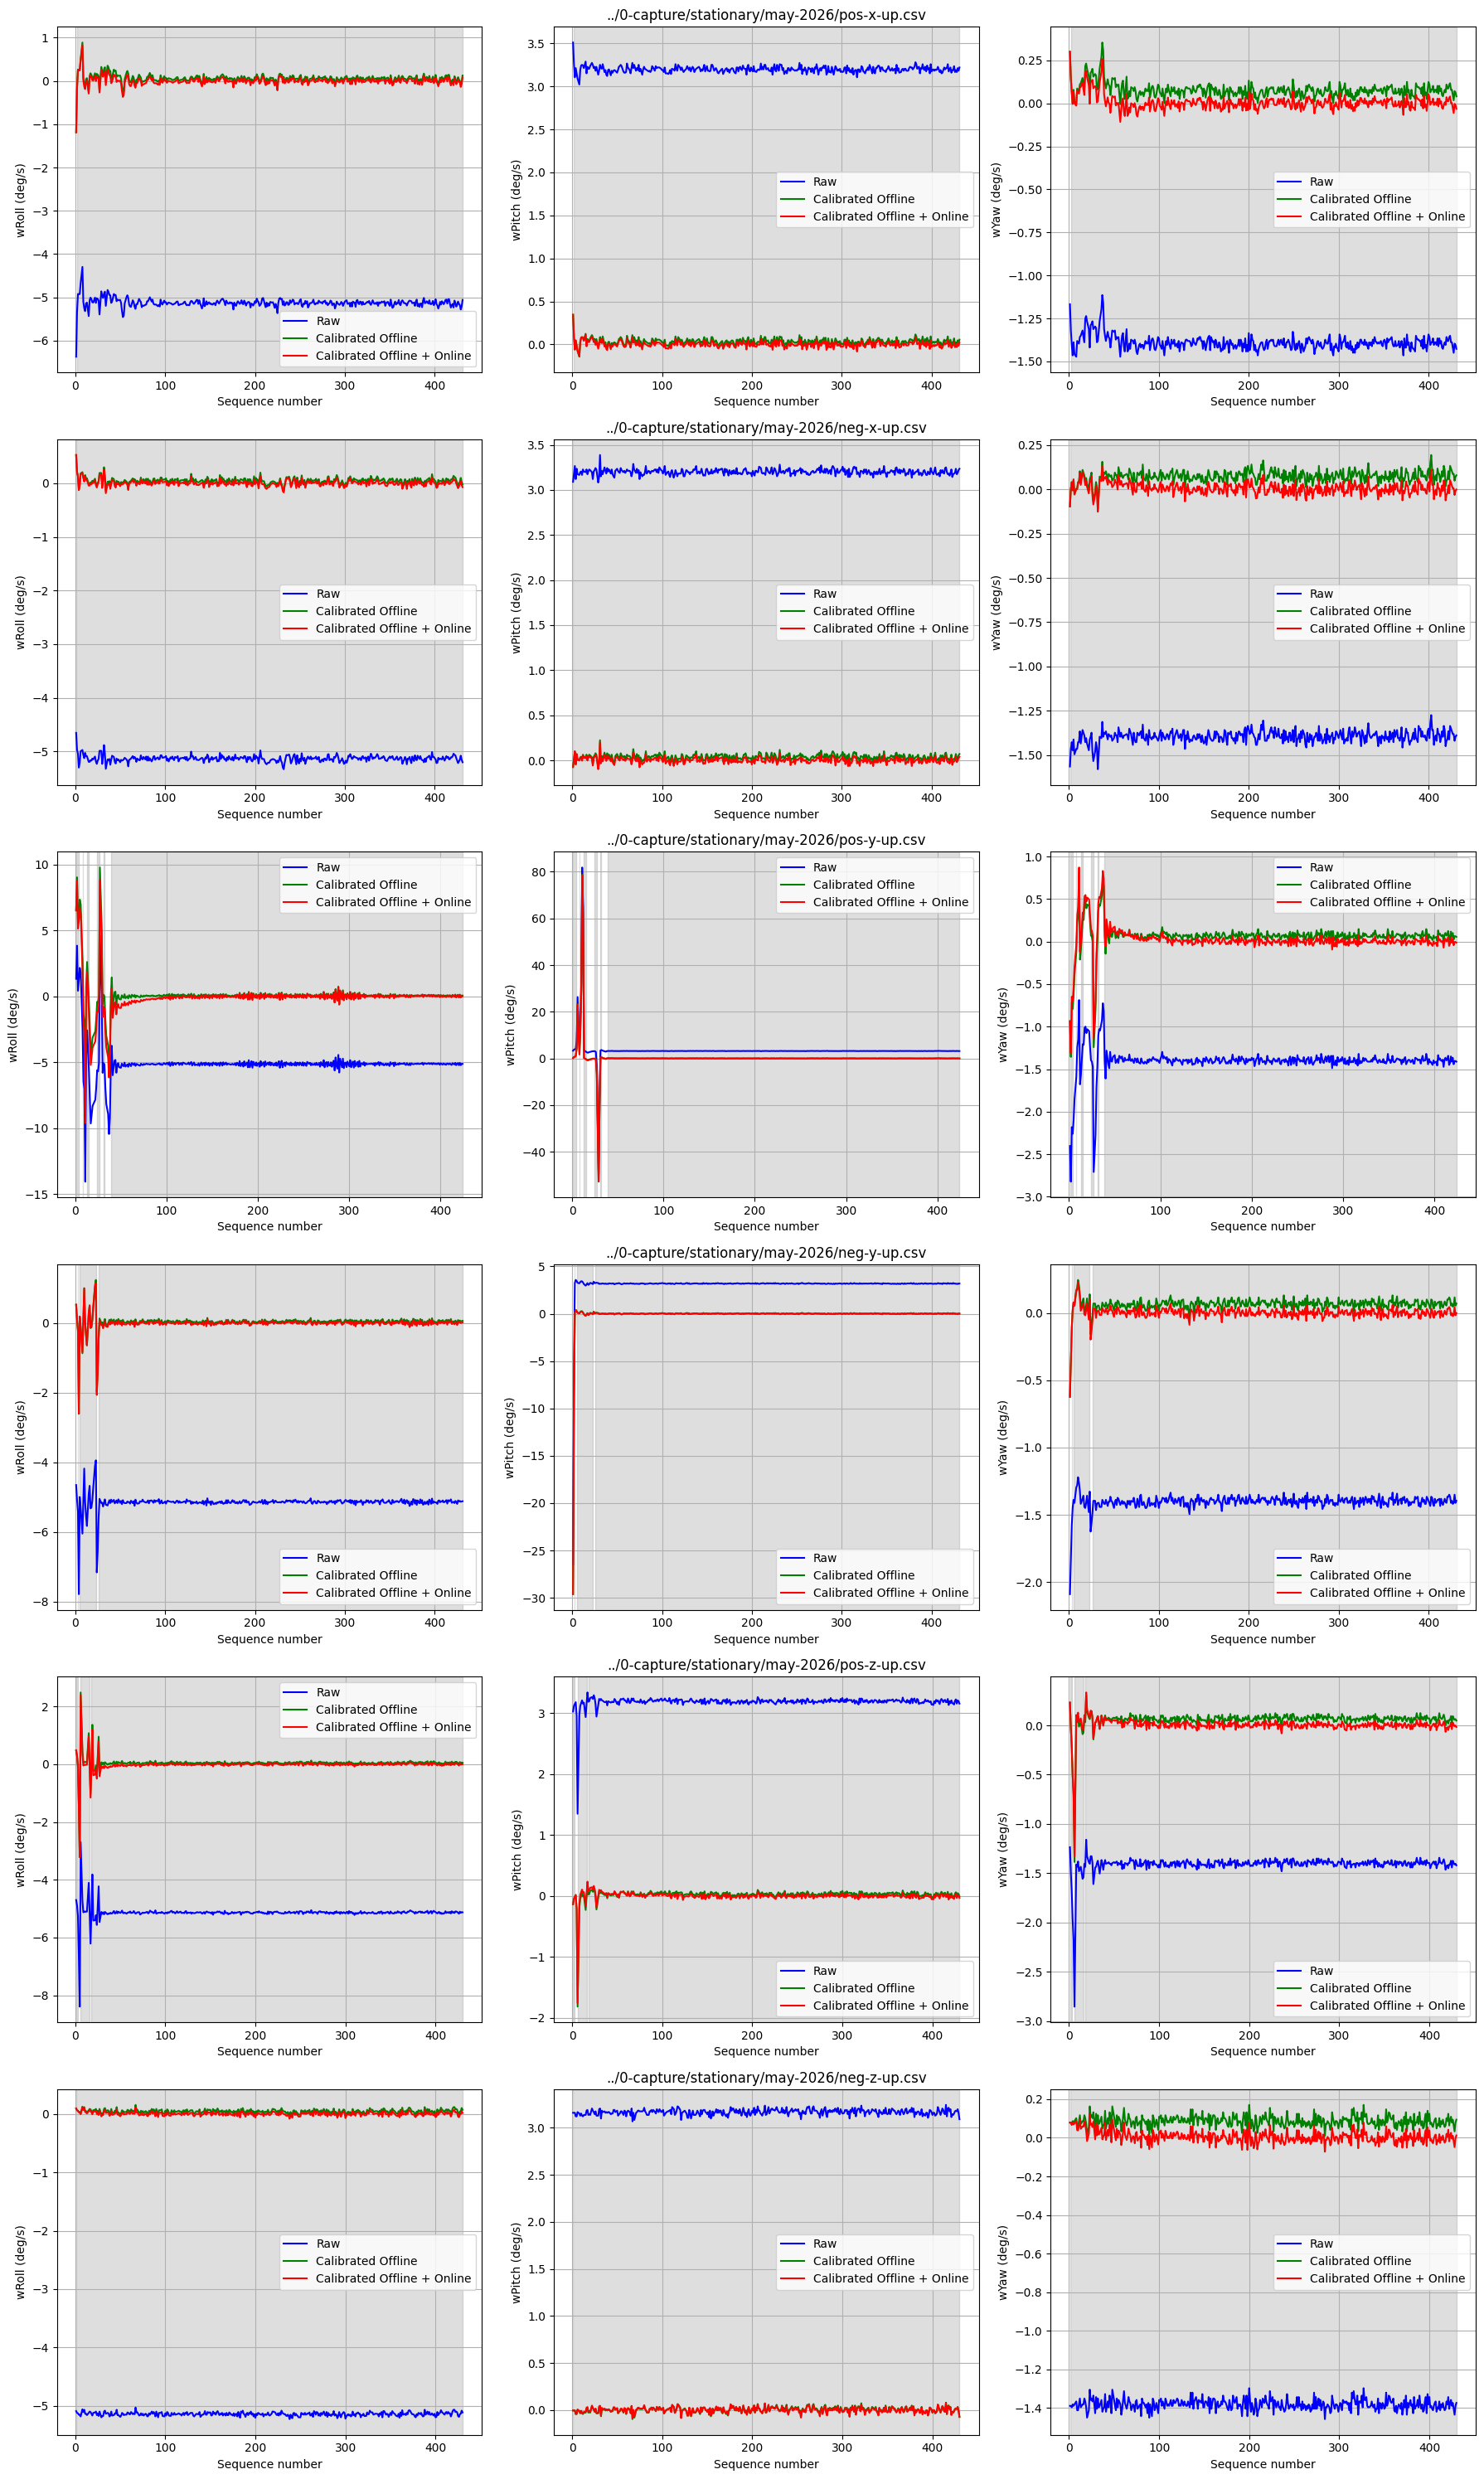

In [ ]:
plotRawAndCalibratedGyroSeries(sixFaceStationaryCaptures)

### Graphical inspection: simple rotations

Both methods also visually work similarly here. I can't judge the moving periods that much as the angular velocity produced by my hands when recording was done is unknown. Further inspection through metrics is needed.

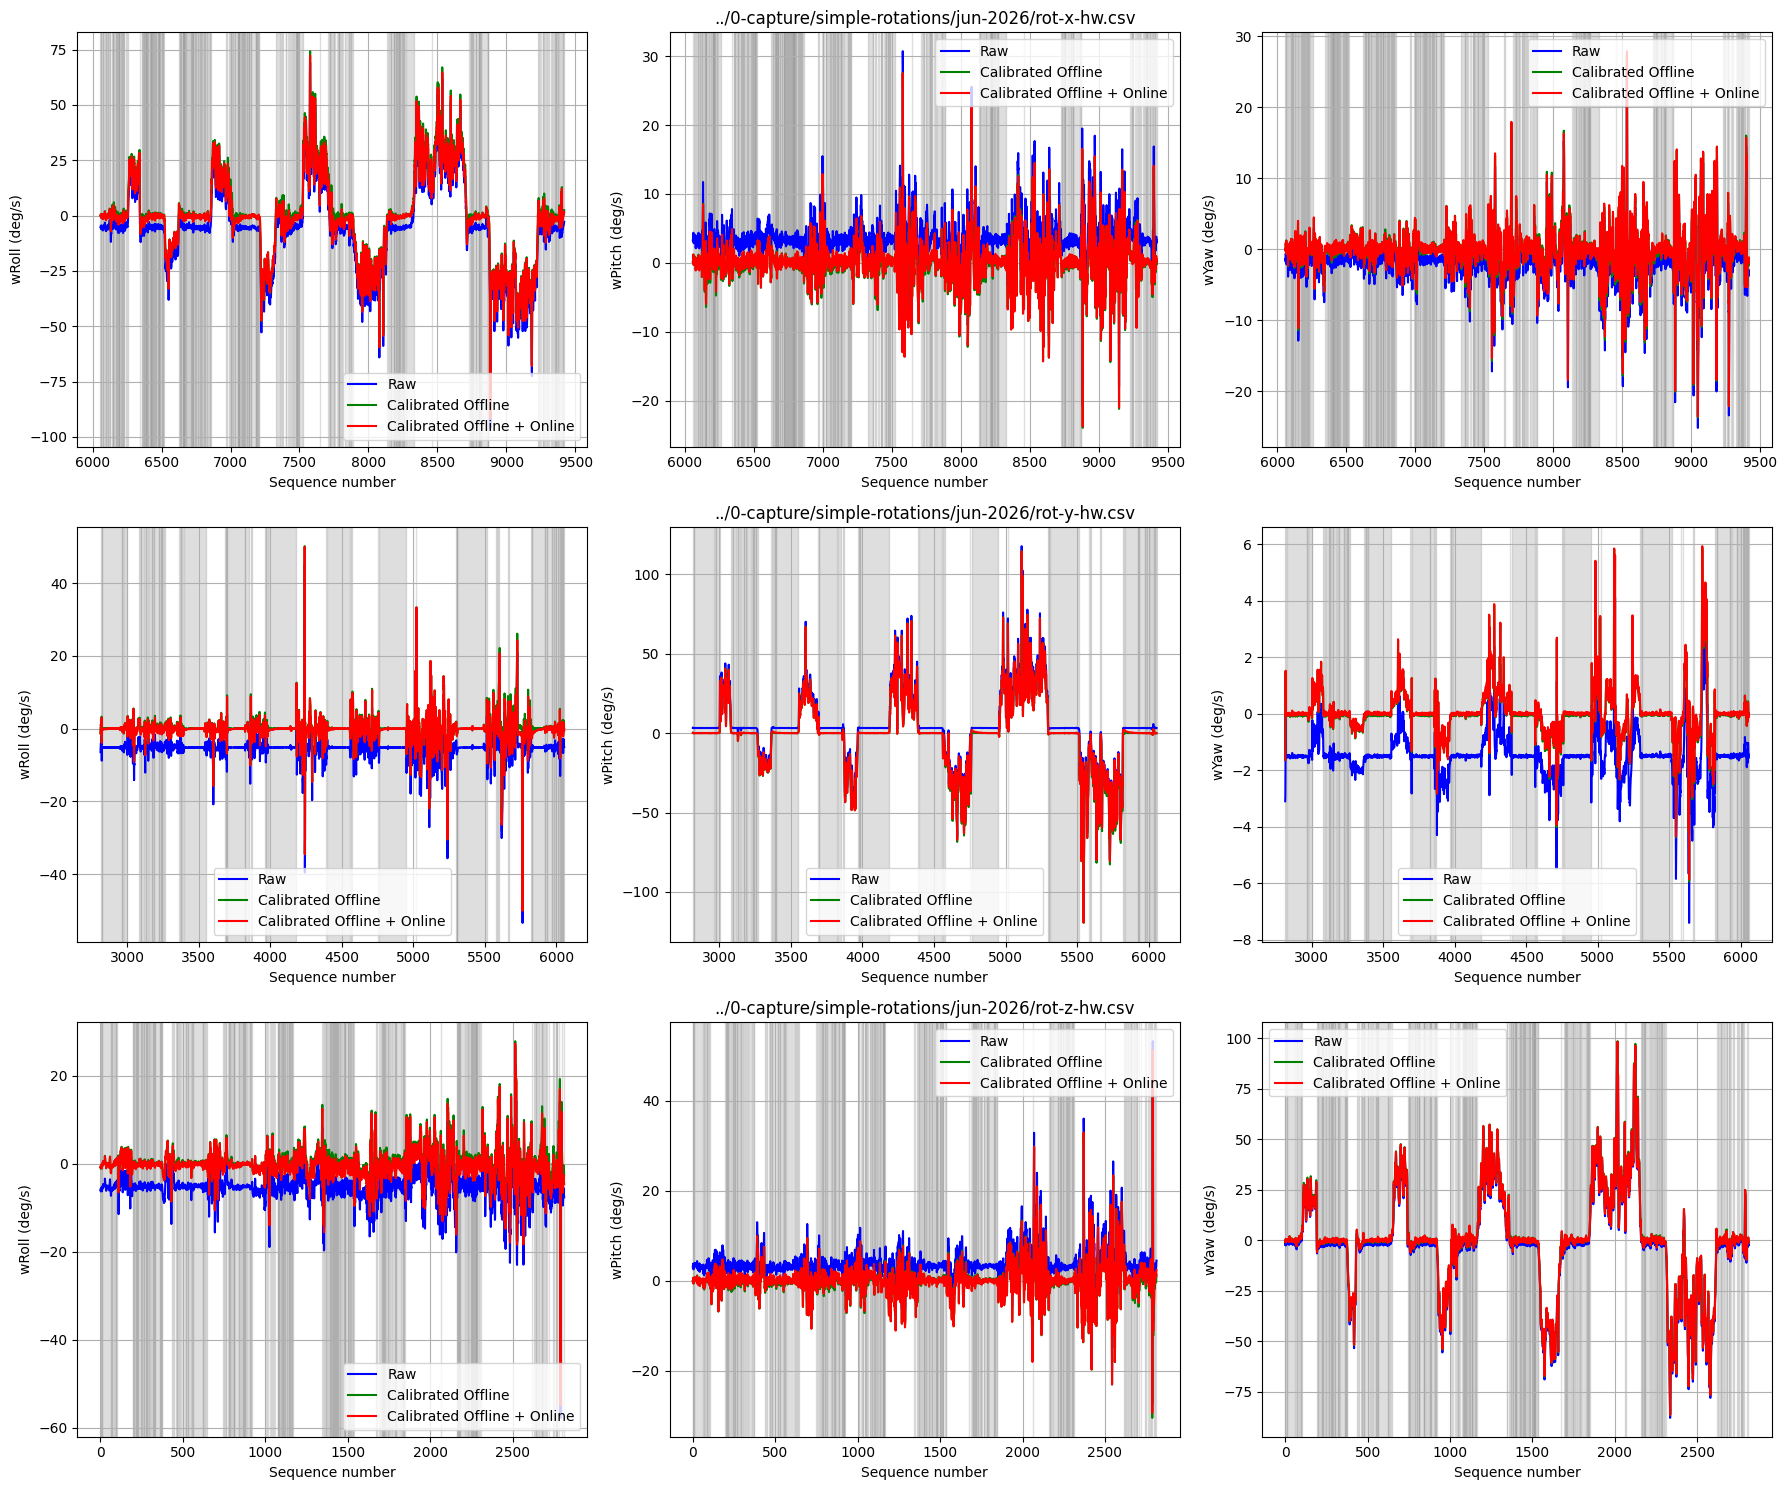

In [ ]:
plotRawAndCalibratedGyroSeries(simpleRotationsCaptures)

### Numerical inspection: offline and offline + online calibration

During stationary periods, the following angular velocity metrics can be computed for each axis:
* Mean: should stay as close to zero as possible, which means better bias removal.
* Standard deviation: should be as low as possible, which means better noise removal.
* RMS: should be as low as possible, which means lower total stationary error.

The offline + online calibration performs significantly better (about one order of magnitude) on bias removal and slightly better on the standard deviation and RMS. This is consistent with the graphical inspection.

In [ ]:
def computeGyroCalibrationMetrics(captures):
    axes = ["wRoll", "wPitch", "wYaw"]
    for capture in captures:
        _, a, w = reader.readRaw(capture)
        stationaryFlags = stationaryChecker.areStationarySamples(a, w)
        wCalibratedOfflineStationary = np.array(
            [
                wCalOffline
                for i, wCalOffline in enumerate(calibrateGyroOffline(a, w))
                if stationaryFlags[i]
            ]
        )
        wCalibratedOnlineStationary = np.array(
            [
                wCalOnline
                for i, wCalOnline in enumerate(calibrateGyroOnline(a, w))
                if stationaryFlags[i]
            ]
        )

        print(f"{capture}:")
        for j, axisName in enumerate(axes):
            offlineAxis = wCalibratedOfflineStationary[:, j]
            onlineAxis = wCalibratedOnlineStationary[:, j]

            offlineAxisMean = np.mean(offlineAxis)
            onlineAxisMean = np.mean(onlineAxis)
            print(f"\t{axisName}:")
            print(
                f"\t\tmean: offline={offlineAxisMean:.4f}, "
                f"online={onlineAxisMean:.4f},",
                f"diff={offlineAxisMean - onlineAxisMean:.4f},",
                f"ratio={offlineAxisMean / onlineAxisMean:.4f}",
            )

            offlineAxisStd = np.std(offlineAxis)
            onlineAxisStd = np.std(onlineAxis)
            print(
                f"\t\tstd:  offline={offlineAxisStd:.4f}, "
                f"online={onlineAxisStd:.4f}, "
                f"diff={offlineAxisStd - onlineAxisStd:.4f}, "
                f"ratio={offlineAxisStd / onlineAxisStd:.4f}"
            )

            offlineAxisRMS = np.sqrt(np.mean(offlineAxis**2))
            onlineAxisRMS = np.sqrt(np.mean(onlineAxis**2))
            print(
                f"\t\tRMS:  offline={offlineAxisRMS:.4f}, "
                f"online={onlineAxisRMS:.4f}, "
                f"diff={offlineAxisRMS - onlineAxisRMS:.4f}, "
                f"ratio={offlineAxisRMS / onlineAxisRMS:.4f}\n"
            )


print("Gyroscope calibration metrics for stationary captures:")
computeGyroCalibrationMetrics(sixFaceStationaryCaptures)
print("\nGyroscope calibration metrics for simple rotations captures:")
computeGyroCalibrationMetrics(simpleRotationsCaptures)

Gyroscope calibration metrics for stationary captures:
../0-capture/stationary/may-2026/pos-x-up.csv:
	wRoll:
		mean: offline=0.0595, online=0.0030, diff=0.0565, ratio=19.5797
		std:  offline=0.0886, online=0.0872, diff=0.0015, ratio=1.0169
		RMS:  offline=0.1068, online=0.0872, diff=0.0196, ratio=1.2243

	wPitch:
		mean: offline=0.0329, online=0.0025, diff=0.0304, ratio=13.4041
		std:  offline=0.0329, online=0.0326, diff=0.0003, ratio=1.0104
		RMS:  offline=0.0465, online=0.0327, diff=0.0139, ratio=1.4244

	wYaw:
		mean: offline=0.0762, online=0.0053, diff=0.0709, ratio=14.4624
		std:  offline=0.0402, online=0.0413, diff=-0.0011, ratio=0.9741
		RMS:  offline=0.0862, online=0.0416, diff=0.0445, ratio=2.0708

../0-capture/stationary/may-2026/neg-x-up.csv:
	wRoll:
		mean: offline=0.0481, online=0.0049, diff=0.0431, ratio=9.7676
		std:  offline=0.0579, online=0.0583, diff=-0.0004, ratio=0.9926
		RMS:  offline=0.0752, online=0.0585, diff=0.0167, ratio=1.2853

	wPitch:
		mean: offline=0.036

## Export results

In [ ]:
def exportResults(captures):
    for capture in captures:
        seq, a, w = reader.readRaw(capture)
        aCalibrated = calibrateAccel(a, "both")
        wCalibratedOffline = calibrateGyroOffline(a, w)
        wCalibratedOnline = calibrateGyroOnline(a, w)

        oldFileName = capture.split("/")[-1].split(".")[0]
        writer.writeRaw(
            f"./output/{oldFileName}-calib-affine-a-offline-w.csv",
            seq,
            aCalibrated,
            wCalibratedOffline,
        )
        writer.writeRaw(
            f"./output/{oldFileName}-calib-affine-a-online-w.csv",
            seq,
            aCalibrated,
            wCalibratedOnline,
        )


exportResults(sixFaceStationaryCaptures)
exportResults(simpleRotationsCaptures)
exportResults(realExerciseCaptures)